# ARIM-Academy：CNNによるSEM画像からのナノ構造体の分類 ― Xceptionによる転移学習
### 機器：走査電子顕微鏡（SEM）
### 分析：転移学習・ファインチューニング（Xception）

## このノートブックについて

| 項目 | 内容 |
| --- | --- |
| **対象読者** | `1_LeNet-5.ipynb` と `2_CNN.ipynb` を終えた方。Kerasで層を組む書き方と、CNNで画像を分類する流れを一度たどったことがある方 |
| **前提知識** | 深層学習の理論的背景は前提としません。前2冊で扱った「訓練/検証/テストの3分割」「macro-F1」「多数派ベースライン」の考え方はそのまま使います。層の書き方は `Functional API`（1冊目の5節）を使います |
| **学べること** | ①転移学習が有効な理由、②事前学習済みモデル固有の前処理（`preprocess_input`）の意味、③特徴抽出とファインチューニングの2段階戦略、④ゼロから学習したモデルとの公平な比較のしかた |
| **動作環境** | Google Colab（**GPUランタイム強く推奨**）または ローカルの Python 3.10+ / TensorFlow 2.16+ / OpenCV / scikit-learn / pandas / matplotlib / seaborn |
| **ネットワーク** | ImageNet事前学習済み重み（約80MB）を初回実行時にダウンロードします。オフライン環境では実行できません |
| **所要時間** | GPU環境で約15〜25分 |
| **データのライセンス** | 原データセットは CC BY 4.0（Aversa et al., *Sci Data* 5, 180172, 2018） |
| **本ノートブックのライセンス** | MIT License |
| **バージョン** | 第2版（2026-07-26 改訂） |

### シリーズ全3冊の地図

| # | ノートブック | ねらい |
| --- | --- | --- |
| 1 | `1_LeNet-5.ipynb` | **歴史編・文法編**：1998年のLeNet-5を原典に忠実に再現し、Kerasで層を組む文法を1つずつ習得する |
| 2 | `2_CNN.ipynb` | **現代化編**：LeNet-5を出発点に、解像度・活性化関数・プーリング・正則化を現代的な設計へ更新し、ハイパーパラメータを探索する |
| 3 | `3_Xception.ipynb` ←**本書** | **転移学習編**：ImageNetで事前学習されたXceptionを流用し、ゼロから学習したCNNと比較する |

3冊は**この順に読む前提**で書かれています。前の冊で導入した用語・評価の枠組み（多数派ベースライン、balanced accuracy、macro-F1、訓練/検証/テストの3分割）は、後の冊でも同じ意味で使います。ただしコードはそれぞれ独立して実行できるよう、セットアップとデータ読み込みは各冊に再掲しています。

> **前2冊との関係**：本ノートブックは単体で最初から実行できます（データの読み込みからやり直します）。ただし最後の比較セクションでは、前2冊が出力した `output/model_comparison_lenet.csv` と `output/model_comparison_cnn.csv` があれば読み込んで並べて表示します。無くてもエラーにはなりません。

## 転移学習とは

前2冊では、重みをランダムな初期値から始めてモデルを学習させました。訓練データはわずか1,023枚です。この枚数で「エッジを検出する」「テクスチャを捉える」といった**画像認識の基礎的な特徴抽出**をゼロから覚えさせるのは、かなり無理があります。

面白いことに、この問題意識は1998年のLeNet-5とも地続きです。1冊目で見たとおり、CNNは「局所受容野・重み共有・サブサンプリング」という工夫によって**少ないパラメータで学習できる**ように設計されました。転移学習はそこからさらに一歩進み、**そもそも学習し直さない**という発想です。

**転移学習（transfer learning）** は、大規模データセット（ここでは約1,400万枚・1,000クラスの ImageNet）で学習済みのモデルを持ってきて、その特徴抽出能力を再利用する手法です。

| 段階 | やること | 学習される重み |
| --- | --- | --- |
| **第1段階：特徴抽出** | 事前学習済みモデルを**凍結**し、その上に載せた分類器だけを学習 | 新しく追加した層のみ |
| **第2段階：ファインチューニング** | 事前学習済みモデルの**上位層だけ凍結を解除**し、非常に小さい学習率で微調整 | 上位層＋分類器 |

順序が重要です。分類器がランダム初期値のまま事前学習済み層の凍結を解くと、初期の大きな勾配が「せっかく学習済みの重み」を壊してしまいます。まず分類器を仕上げてから、そっと微調整する、という2段構えにします。

### Xception について

Xception（Chollet, 2017）は Inception 系のアーキテクチャを **深さ方向分離可能畳み込み（depthwise separable convolution）** で置き換えたモデルです。通常の畳み込みを「空間方向の畳み込み」と「チャンネル方向の畳み込み」に分解することで、パラメータ数を抑えつつ表現力を保ちます。ImageNet で約79%のtop-1精度を持ちながら、パラメータは約2,290万個です。

[2] François Chollet, *Xception: Deep Learning with Depthwise Separable Convolutions*, **CVPR 2017**, DOI: [10.1109/CVPR.2017.195](https://doi.org/10.1109/CVPR.2017.195), arXiv: [1610.02357](https://arxiv.org/abs/1610.02357)

## 0. セットアップ

### Google Colab で実行する場合

<font color="red">ローカル環境で実行する場合は、このセルを実行する必要はありません。</font>

In [1]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_NAME = "Advanced_Tutorial_1_SEM-Image-Classification"
    if not Path(REPO_NAME).exists():
        !git clone --depth 1 https://github.com/ARIM-Academy-ImageRecognition/Advanced_Tutorial_1_SEM-Image-Classification.git
    %cd {REPO_NAME}

print(f"Running on Google Colab: {IN_COLAB}")
print(f"Current working directory: {Path.cwd()}")

Running on Google Colab: False
Current working directory: c:\Users\a013662\Dropbox\ARIM\1_ARIM-Academy-ImageRecognition\Advanced_Tutorial_1_SEM-Image-Classification


### GPUの確認

Xception は `2_CNN.ipynb` の小規模CNNの数十〜100倍のパラメータを持ちます。**CPUのみだと1エポックに数分かかる**ため、GPUランタイムの使用を強く推奨します。

In [2]:
import tensorflow as tf

gpu_devices = tf.config.list_physical_devices("GPU")

if gpu_devices:
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU detected: {[d.name for d in gpu_devices]}")
else:
    print("WARNING: No GPU detected. Training Xception on CPU will be very slow.")
    print("On Colab: Runtime > Change runtime type > Hardware accelerator > GPU")

print(f"TensorFlow version: {tf.__version__}")

On Colab: Runtime > Change runtime type > Hardware accelerator > GPU
TensorFlow version: 2.21.0


### ライブラリのインポートと共通設定

深層学習は乱数（重みの初期値、データのシャッフル順など）に依存します。結果を再現できるよう、乱数シードを一箇所にまとめて固定します。

> **注意**：GPU上の一部の演算は非決定的なため、シードを固定しても実行のたびに小数点以下が変動することがあります。「毎回まったく同じ数値になる」とは限りません。傾向が再現できれば十分です。

In [3]:
import os
import random
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix, f1_score)
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import Xception

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print("Libraries imported. Random seed fixed to", SEED)

Libraries imported. Random seed fixed to 42


### 入出力フォルダの準備

生成物（前処理済みデータ・学習済みモデル・図・CSV）はノートブックと同じ階層に散らかさず、`output/` と `model/` にまとめます。フォルダが無ければ自動で作成します。

In [4]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
TRAIN_DIR = DATA_DIR / "training_data"
PREDICT_DIR = DATA_DIR / "prediction_data"

OUTPUT_DIR = BASE_DIR / "output"
MODEL_DIR = BASE_DIR / "model"
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

assert TRAIN_DIR.exists(), f"Training data not found at {TRAIN_DIR}"

print(f"Data directory  : {TRAIN_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Model directory : {MODEL_DIR}")

Data directory  : c:\Users\a013662\Dropbox\ARIM\1_ARIM-Academy-ImageRecognition\Advanced_Tutorial_1_SEM-Image-Classification\data\training_data
Output directory: c:\Users\a013662\Dropbox\ARIM\1_ARIM-Academy-ImageRecognition\Advanced_Tutorial_1_SEM-Image-Classification\output
Model directory : c:\Users\a013662\Dropbox\ARIM\1_ARIM-Academy-ImageRecognition\Advanced_Tutorial_1_SEM-Image-Classification\model


## 1. データの読み込み

`2_CNN.ipynb` と同じ手順で画像を読み込みますが、**2点だけ変えます**。

1. **入力サイズを 100×100 → 128×128 に拡大**
   Xception は入力を段階的に1/32へ縮小します。100×100 だと最終的な特徴マップが **3×3** しか残らず、空間的な情報がほとんど潰れてしまいます。128×128 なら **4×4** が残ります。なお Xception が受け付ける最小サイズは 71×71 です。

   > **1冊目のLeNet-5を思い出してください。** LeNet-5はC5層で特徴マップがちょうど1×1に収束するよう、入力32×32を前提に設計されていました。「入力サイズと層構成は一体で設計されている」という原則は、2,100万パラメータのXceptionでもまったく同じです。使うモデルが決まったら、そのモデルが何段階の縮小を行うかを確認し、最終的な特徴マップの大きさから逆算して入力サイズを決めます。
2. **3チャンネル（RGB）で保持**
   Xception は ImageNet のカラー画像で学習されているため、入力は3チャンネルである必要があります。SEM画像はグレースケールなので、同じ値を3チャンネルに複製します。

> **キャッシュ形式について**：前処理済みデータは `.npz`（`numpy.savez_compressed`）で保存します。`pickle` は「Pythonオブジェクトを何でも保存できる」便利さの裏返しとして、**読み込み時に任意のコードを実行できてしまう**という安全上の弱点があります。配布物として数値配列だけを保存するなら `.npz` のほうが安全かつ高速です。

In [5]:
CATEGORIES = ["Biological", "Fibres",
              "Films_Coated_Surface", "MEMS_devices_and_electrodes",
              "Nanowires", "Particles",
              "Patterned_surface", "Porous_Sponge",
              "Powder", "Tips"]

NUM_CLASSES = len(CATEGORIES)

# Xception 用の入力サイズ（最小71px。1/32に縮小されるため32の倍数が扱いやすい）
IMG_SIZE = 128

# 実測に基づく定数：情報バーは 636 行目付近から始まるため、余裕をみて 630 行目で切る
DATABAR_TOP_ROW = 630

In [6]:

def load_micrograph(path, img_size=IMG_SIZE, crop_databar=True, as_rgb=True):
    """SEM画像を1枚読み込み、情報バーを除去して正方形にリサイズする。

    1冊目（1_CNN_baseline.ipynb）と同一の実装。as_rgb=True では
    OpenCV の BGR 順を RGB 順に並べ替えたうえで3チャンネルで返す。
    """
    flag = cv2.IMREAD_COLOR if as_rgb else cv2.IMREAD_GRAYSCALE
    image = cv2.imread(str(path), flag)
    if image is None:
        raise ValueError(f"Failed to read image: {path}")

    if as_rgb:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    if crop_databar and image.shape[0] > DATABAR_TOP_ROW:
        image = image[:DATABAR_TOP_ROW, :]

    resized = cv2.resize(image, (img_size, img_size), interpolation=cv2.INTER_AREA)
    if not as_rgb:
        resized = resized[:, :, np.newaxis]
    return resized


def build_dataset(categories, img_size=IMG_SIZE, as_rgb=True, verbose=True):
    """カテゴリ別フォルダから全画像を読み込み、特徴量Xとラベルyを返す。"""
    images, labels, failures = [], [], []

    for class_index, category in enumerate(categories):
        paths = sorted((TRAIN_DIR / category).glob("*.jpg"))
        for path in paths:
            try:
                images.append(load_micrograph(path, img_size=img_size, as_rgb=as_rgb))
                labels.append(class_index)
            except ValueError as error:
                failures.append((path.name, str(error)))
        if verbose:
            print(f"  {category:30s} loaded {len(paths):4d} images")

    if failures:
        print(f"\nWARNING: {len(failures)} image(s) could not be read.")

    return np.stack(images).astype(np.uint8), np.asarray(labels, dtype=np.int64)

In [7]:

CACHE_PATH = OUTPUT_DIR / f"sem_dataset_rgb_{IMG_SIZE}.npz"

start = time.time()
if CACHE_PATH.exists():
    with np.load(CACHE_PATH) as cached:
        X, y = cached["X"], cached["y"]
    print(f"Loaded cached dataset from {CACHE_PATH.name}")
else:
    X, y = build_dataset(CATEGORIES)
    np.savez_compressed(CACHE_PATH, X=X, y=y)
    print(f"Saved dataset cache to {CACHE_PATH.name}")

print(f"Elapsed: {time.time() - start:.1f} s")
print(f"X: shape={X.shape}, dtype={X.dtype}, range=[{X.min()}, {X.max()}]")
print(f"Memory used by X: {X.nbytes / 1e6:.1f} MB")

class_counts = pd.Series(y).value_counts().sort_index()
class_counts.index = CATEGORIES
majority_baseline = class_counts.max() / class_counts.sum()
print(f"\nMajority-class baseline accuracy = {majority_baseline:.4f} "
      f"(always predicting '{class_counts.idxmax()}')")

  Biological                     loaded  100 images
  Fibres                         loaded  100 images
  Films_Coated_Surface           loaded  100 images
  MEMS_devices_and_electrodes    loaded  100 images
  Nanowires                      loaded  100 images
  Particles                      loaded  100 images
  Patterned_surface              loaded  100 images
  Porous_Sponge                  loaded  100 images
  Powder                         loaded  895 images
  Tips                           loaded   10 images
Saved dataset cache to sem_dataset_rgb_128.npz
Elapsed: 110.8 s
X: shape=(1705, 128, 128, 3), dtype=uint8, range=[0, 255]
Memory used by X: 83.8 MB

Majority-class baseline accuracy = 0.5249 (always predicting 'Powder')


### 前2冊とまったく同じ分割を再現する

モデルを比較するには、**同じテストデータで評価する**必要があります。前2冊と同じ関数・同じシード・同じ層化条件でインデックスを分割すれば、結果は完全に一致します。最後に出力される「チェックサム」が前2冊の出力と同じであることを確認してください。

In [8]:
all_indices = np.arange(len(y))

idx_trainval, idx_test = train_test_split(
    all_indices, test_size=0.2, random_state=SEED, stratify=y)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.25, random_state=SEED, stratify=y[idx_trainval])

X_train, y_train = X[idx_train], y[idx_train]
X_val, y_val = X[idx_val], y[idx_val]
X_test, y_test = X[idx_test], y[idx_test]

assert len(set(idx_train) & set(idx_val)) == 0
assert len(set(idx_train) & set(idx_test)) == 0
assert len(set(idx_val) & set(idx_test)) == 0

for name, labels in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:5s}: {len(labels):5d} samples ({len(labels) / len(y):.0%})")

print(f"\nSplit checksum (sum of test indices) = {idx_test.sum()}")
print("-> This value must match the checksum printed in 1_LeNet-5.ipynb and 2_CNN.ipynb.")

train:  1023 samples (60%)
val  :   341 samples (20%)
test :   341 samples (20%)

Split checksum (sum of test indices) = 290658
-> This value must match the checksum printed in 1_LeNet-5.ipynb and 2_CNN.ipynb.


## 2. 事前学習済みモデル固有の前処理

**ここは、事前学習済みモデルを使うときに最も間違えやすい箇所です。**

ImageNet で学習されたモデルは、それぞれ「学習時に使ったのと同じスケールの入力」を期待します。Xception の場合は `keras.applications.xception.preprocess_input()` が使われ、その中身は

$$ x_{\text{scaled}} = \frac{x}{127.5} - 1 $$

つまり **0〜255 を −1〜+1 に変換**する処理です。

`2_CNN.ipynb` では `/255`（0〜1）を使いました。**同じ感覚で Xception に 0〜1 を渡すと、事前学習済みの重みが想定する分布と食い違い、事前学習の恩恵を十分に受けられません。** しかも動いてしまうので、バグに気づけません。

前処理の流儀はモデルごとに違います。

| モデル | `preprocess_input` の中身 |
| --- | --- |
| Xception, MobileNet, InceptionV3 | `x / 127.5 - 1`（**[-1, 1]**） |
| VGG16, VGG19, ResNet50 | チャンネルごとにImageNetの平均を引く（**[0, 255] 基準**） |
| EfficientNet（Keras実装） | モデル内部で正規化するため、**生の [0, 255] をそのまま渡す** |

**使うモデルの `preprocess_input` を必ず確認してください。** 本書では `layers.Rescaling(scale=1/127.5, offset=-1)` を**モデルの先頭に組み込みます**。これは Xception の `preprocess_input()` と数学的に同一で、かつ「推論時に前処理を忘れる」事故を構造的に防げます（前2冊と同じ考え方です）。

In [9]:
from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess

# Rescaling(1/127.5, offset=-1) が preprocess_input と同一であることを実データで確認する
sample_batch = X_train[:8].astype("float32")

via_function = xception_preprocess(sample_batch.copy())
via_layer = layers.Rescaling(scale=1.0 / 127.5, offset=-1.0)(sample_batch).numpy()

max_difference = np.abs(via_function - via_layer).max()
print(f"preprocess_input() range : [{via_function.min():.3f}, {via_function.max():.3f}]")
print(f"Rescaling layer range    : [{via_layer.min():.3f}, {via_layer.max():.3f}]")
print(f"Maximum absolute difference: {max_difference:.2e}")
assert max_difference < 1e-5, "Rescaling layer does not match preprocess_input"
print("\nOK: the Rescaling layer is equivalent to xception.preprocess_input().")

preprocess_input() range : [-0.976, 1.000]
Rescaling layer range    : [-0.976, 1.000]
Maximum absolute difference: 1.19e-07

OK: the Rescaling layer is equivalent to xception.preprocess_input().


### 図1：前処理によって画素値の分布がどう変わるか

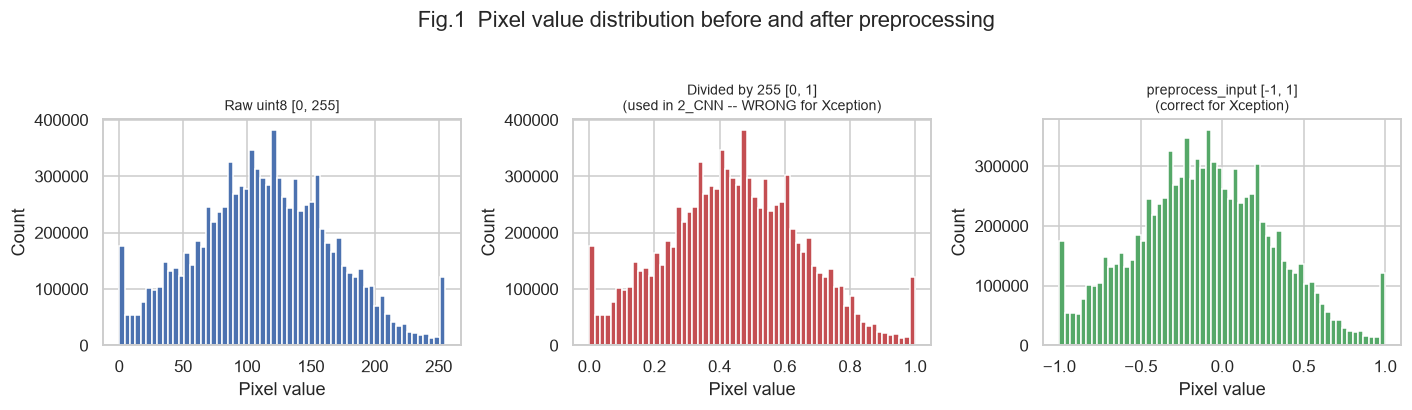

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
distributions = [
    (X_train[:200].ravel(), "Raw uint8 [0, 255]", "#4C72B0"),
    ((X_train[:200] / 255.0).ravel(), "Divided by 255 [0, 1]\n(used in 2_CNN -- WRONG for Xception)", "#C44E52"),
    (xception_preprocess(X_train[:200].astype("float32")).ravel(),
     "preprocess_input [-1, 1]\n(correct for Xception)", "#55A868"),
]

for ax, (values, title, color) in zip(axes, distributions):
    ax.hist(values, bins=60, color=color)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Pixel value")
    ax.set_ylabel("Count")

fig.suptitle("Fig.1  Pixel value distribution before and after preprocessing", y=1.03)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig01_preprocessing_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. 評価用のヘルパー関数

前2冊と同一の実装です。指標を揃えることが、公平な比較の前提になります。

In [12]:
def predict_proba(model, features, batch_size=32):
    """モデルのロジット出力をソフトマックスで確率に変換して返す。"""
    logits = model.predict(features, batch_size=batch_size, verbose=0)
    return tf.nn.softmax(logits).numpy()


def evaluate_classifier(model, features, y_true, model_name, split_name):
    """分類モデルを評価し、主要指標を辞書で返す。"""
    y_proba = predict_proba(model, features)
    y_pred = np.argmax(y_proba, axis=1)

    scores = {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    return scores, y_pred, y_proba


def plot_confusion_matrix(y_true, y_pred, class_names, title, filename, normalize=True):
    """混同行列を描画して保存する。normalize=True では行方向に正規化する。"""
    matrix = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))

    if normalize:
        row_sums = matrix.sum(axis=1, keepdims=True)
        display_matrix = np.divide(matrix, row_sums, where=row_sums != 0)
        fmt, vmax, cbar_label = ".2f", 1.0, "Recall (row-normalised)"
    else:
        display_matrix = matrix
        fmt, vmax, cbar_label = "d", None, "Number of images"

    fig, ax = plt.subplots(figsize=(8.5, 7))
    sns.heatmap(display_matrix, annot=True, fmt=fmt, square=True,
                cmap="Blues", vmin=0, vmax=vmax,
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={"label": cbar_label}, ax=ax)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
    plt.setp(ax.get_yticklabels(), rotation=0)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()
    return matrix


def plot_learning_curves(histories, title, filename):
    """1つ以上の学習履歴を連結して学習曲線を描画する。

    histories : list of (label, keras.callbacks.History)
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    epoch_offset = 0

    for label, history in histories:
        epochs = np.arange(len(history.history["loss"])) + epoch_offset
        axes[0].plot(epochs, history.history["loss"], label=f"{label} (train)")
        axes[0].plot(epochs, history.history["val_loss"], ls="--", label=f"{label} (val)")
        axes[1].plot(epochs, history.history["accuracy"], label=f"{label} (train)")
        axes[1].plot(epochs, history.history["val_accuracy"], ls="--", label=f"{label} (val)")
        epoch_offset += len(history.history["loss"])
        if len(histories) > 1:
            for ax in axes:
                ax.axvline(epoch_offset - 0.5, color="gray", lw=0.8, ls=":")

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend(fontsize=8)

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].axhline(majority_baseline, color="gray", ls="--", lw=1,
                    label=f"majority baseline ({majority_baseline:.3f})")
    axes[1].legend(fontsize=8)

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()

print("Helper functions defined.")

Helper functions defined.


## 4. 第1段階：特徴抽出（ベースモデルを凍結）

Xception の畳み込み部分（`include_top=False`）を**凍結**し、その上に分類器を載せます。

**モデルの構造**

```
入力 (128, 128, 3) uint8
  ↓ Rescaling(1/127.5, offset=-1)   ← preprocess_input と同一
  ↓ Xception 畳み込み部（凍結、20,861,480 パラメータ）
  ↓ GlobalAveragePooling2D          ← (4, 4, 2048) を (2048,) に圧縮
  ↓ Dropout(0.3)                    ← 過学習の抑制
  ↓ Dense(10)                       ← ロジット出力
```

**書き方は Functional API**：ここでは `Sequential` ではなく、1冊目の5節で練習した Functional API（`x = layer(x)` と通していく書き方）を使います。事前学習済みモデルを「1つの巨大な層」として途中に差し込むには、この書き方のほうが自然だからです。

**`GlobalAveragePooling2D` を使う理由**：`Flatten` だと 4×4×2048 = 32,768 次元になり、続く全結合層のパラメータが爆発します。空間方向に平均を取れば 2,048 次元で済み、位置のずれにも強くなります。1冊目のLeNet-5がC5層で1×1まで縮めてから `Flatten` していたのも、動機は同じ（全結合層のパラメータを抑える）でした。

**`BatchNormalization` の扱い**：Xception には多数の `BatchNormalization` 層が含まれます。Keras では `layer.trainable = False` を設定するとバッチ正規化は**推論モード**（移動平均を使い、統計量を更新しない）で動作します。これは転移学習で意図した挙動です。凍結しているつもりで統計量だけ更新されると、性能が静かに劣化します。

In [13]:
def build_xception_classifier(input_shape, num_classes, dropout_rate=0.3):
    """Xceptionを特徴抽出器として使う分類モデルを構築する。

    前処理（-1〜1へのスケーリング）をモデル内部に持たせているため、
    このモデルには 0〜255 の uint8 画像をそのまま入力してよい。
    """
    base_model = Xception(include_top=False, weights="imagenet",
                          input_shape=input_shape)
    base_model.trainable = False  # 第1段階では凍結

    inputs = keras.Input(shape=input_shape, name="micrograph")
    x = layers.Rescaling(scale=1.0 / 127.5, offset=-1.0, name="xception_preprocess")(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(dropout_rate, name="dropout")(x)
    outputs = layers.Dense(num_classes, name="logits")(x)

    model = keras.Model(inputs, outputs, name="xception_transfer")
    return model, base_model


keras.utils.set_random_seed(SEED)

input_shape = (IMG_SIZE, IMG_SIZE, 3)
model, base_model = build_xception_classifier(input_shape, NUM_CLASSES)
model.summary()

print(f"\nBase model output shape: {base_model.output_shape}")
print(f"Trainable parameters    : {sum(np.prod(w.shape) for w in model.trainable_weights):,}")
print(f"Non-trainable parameters: {sum(np.prod(w.shape) for w in model.non_trainable_weights):,}")

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 41s 0us/step


Model: "xception_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ micrograph (InputLayer)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception_preprocess (Rescaling) │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 4, 4, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,881,970 (79.66 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 20,861,480 (79.58 MB)


Base model output shape: (None, 4, 4, 2048)
Trainable parameters    : 20,490
Non-trainable parameters: 20,861,480


### 学習（第1段階）

凍結した状態では学習される重みが約27万個（うちほとんどは `Dense(128)`）しかないため、学習率は通常どおり 1e-3 で構いません。1冊目のLeNet-5（約6万パラメータ）と同じくらいの規模を学習していることになります。**2,100万パラメータのモデルを使いながら、実際に動かしているのはごく一部だけ**、というのが特徴抽出段階の要点です。

In [15]:
STAGE1_EPOCHS = 30
BATCH_SIZE = 32

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"])

stage1_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(MODEL_DIR / "xception_feature_extraction.keras",
                                    monitor="val_loss", save_best_only=True),
]

start = time.time()
history_stage1 = model.fit(
    X_train, y_train,
    epochs=STAGE1_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=stage1_callbacks,
    verbose=2)
print(f"\nStage 1 finished in {time.time() - start:.1f} s "
      f"({len(history_stage1.history['loss'])} epochs)")

Epoch 1/30
32/32 - 140s - 4s/step - accuracy: 0.7683 - loss: 0.9869 - val_accuracy: 0.7625 - val_loss: 0.9772
Epoch 2/30
32/32 - 165s - 5s/step - accuracy: 0.8084 - loss: 0.7940 - val_accuracy: 0.7683 - val_loss: 0.8988
Epoch 3/30


OSError: [Errno 22] Invalid argument: 'c:\\Users\\a013662\\Dropbox\\ARIM\\1_ARIM-Academy-ImageRecognition\\Advanced_Tutorial_1_SEM-Image-Classification\\model\\xception_feature_extraction.keras'

In [ ]:
results = []

scores, y_pred_stage1, _ = evaluate_classifier(
    model, X_test, y_test, "C: Xception (feature extraction)", "test")
results.append(scores)
scores_val, _, _ = evaluate_classifier(
    model, X_val, y_val, "C: Xception (feature extraction)", "val")

print(pd.DataFrame([scores_val, scores]).round(4).to_string(index=False))
print(f"\nMajority-class baseline accuracy for reference: {majority_baseline:.4f}")

## 5. 第2段階：ファインチューニング

第1段階で分類器が仕上がったので、Xception の**上位ブロックだけ**凍結を解除して微調整します。

**なぜ上位層だけなのか。** CNNの下位層は「エッジ」「色の変化」といった汎用的な特徴を、上位層は「犬の顔」「車輪」のようなデータセット固有の特徴を捉えます。SEM画像には ImageNet の物体そのものは写っていませんが、下位層の汎用的な特徴は流用できます。書き換えたいのは上位層のほうです。

**なぜ学習率を下げるのか。** 事前学習済みの重みは既に良い場所にあります。通常の学習率で更新すると、その情報を壊してしまいます（**破滅的忘却**）。1e-5 程度、つまり第1段階の1/100まで下げるのが定石です。

**`BatchNormalization` は推論モードのままにする。** モデル構築時に `base_model(x, training=False)` と書いているため、凍結を解除した後もバッチ正規化層は移動平均を使い続け、統計量を更新しません。訓練データが1,023枚と少ない状況でバッチ統計を更新すると、事前学習で得た安定した統計量が壊れて性能が落ちます。これは Keras 公式の転移学習ガイドでも推奨されている書き方です。

**再コンパイルを忘れない。** `trainable` を変更したあとに `model.compile()` を呼び直さないと、変更が学習に反映されません。これは非常に見つけにくい不具合です。

In [16]:
# Xception の層名は block1_... 〜 block14_... という構造になっている
FINE_TUNE_FROM_BLOCK = "block13"

base_model.trainable = True

# 指定ブロックが実在することを先に確認する（層名を間違えると黙って0層になる）
block_names = sorted({name.split("_")[0] for layer in base_model.layers
                      for name in [layer.name] if name.startswith("block")})
assert FINE_TUNE_FROM_BLOCK in block_names, (
    f"'{FINE_TUNE_FROM_BLOCK}' not found. Available blocks: {block_names}")

# 指定ブロックより前をすべて凍結する
unfreeze = False
frozen_layers, trainable_layers = 0, 0
for layer in base_model.layers:
    if layer.name.startswith(FINE_TUNE_FROM_BLOCK):
        unfreeze = True
    layer.trainable = unfreeze
    if unfreeze:
        trainable_layers += 1
    else:
        frozen_layers += 1

assert trainable_layers > 0, "No layer was unfrozen -- check FINE_TUNE_FROM_BLOCK."

print(f"Available blocks: {block_names}")
print(f"Fine-tuning from '{FINE_TUNE_FROM_BLOCK}' onwards")
print(f"  frozen layers   : {frozen_layers}")
print(f"  trainable layers: {trainable_layers}")

# 凍結状態を変えたら必ず再コンパイルする（忘れると設定が反映されない）
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"])

print(f"\nTrainable parameters after unfreezing: "
      f"{sum(np.prod(w.shape) for w in model.trainable_weights):,}")

Available blocks: ['block1', 'block10', 'block11', 'block12', 'block13', 'block14', 'block2', 'block3', 'block4', 'block5', 'block6', 'block7', 'block8', 'block9']
Fine-tuning from 'block13' onwards
  frozen layers   : 116
  trainable layers: 16

Trainable parameters after unfreezing: 6,808,874


In [ ]:
STAGE2_EPOCHS = 20

stage2_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(MODEL_DIR / "xception_finetuned.keras",
                                    monitor="val_loss", save_best_only=True),
]

start = time.time()
history_stage2 = model.fit(
    X_train, y_train,
    epochs=STAGE2_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=stage2_callbacks,
    verbose=2)
print(f"\nStage 2 finished in {time.time() - start:.1f} s "
      f"({len(history_stage2.history['loss'])} epochs)")

Epoch 1/20


### 図2：2段階の学習曲線

点線の縦線が第1段階と第2段階の境目です。ファインチューニング開始直後に損失が一段下がるのが典型的な挙動です。逆に**急激に悪化したら学習率が高すぎる**サインなので、1e-6 に下げてみてください。

In [ ]:
plot_learning_curves(
    [("stage 1: feature extraction", history_stage1),
     ("stage 2: fine-tuning", history_stage2)],
    "Fig.2  Two-stage transfer learning curves (Xception)",
    "fig02_learning_curves_xception.png")

In [ ]:
scores_ft_val, _, _ = evaluate_classifier(
    model, X_val, y_val, "D: Xception (fine-tuned)", "val")
scores_ft, y_pred_finetuned, y_proba_finetuned = evaluate_classifier(
    model, X_test, y_test, "D: Xception (fine-tuned)", "test")
results.append(scores_ft)

print(pd.DataFrame([scores_ft_val, scores_ft]).round(4).to_string(index=False))
print()
print(classification_report(y_test, y_pred_finetuned, labels=range(NUM_CLASSES),
                            target_names=CATEGORIES, digits=3, zero_division=0))

### 図3：ファインチューニング後の混同行列

In [ ]:
_ = plot_confusion_matrix(
    y_test, y_pred_finetuned, CATEGORIES,
    "Fig.3  Confusion matrix of the fine-tuned Xception (test set, row-normalised)",
    "fig03_confusion_xception.png")

## 6. モデル比較 ― シリーズ3冊の総まとめ

1998年のLeNet-5、現代的な小規模CNN、そして事前学習済みXceptionを、**同一のテストデータ**で並べます。前2冊が出力したCSVがあれば自動的に読み込みます。

これがシリーズを通した最終的な答え合わせです。読み取るべきは順位そのものよりも、**「何を変えたら、どれだけ動いたか」**という対応関係です。

In [ ]:
majority_class = int(pd.Series(y_train).value_counts().idxmax())
y_pred_majority = np.full_like(y_test, majority_class)

baseline_row = {
    "model": "0: majority-class baseline",
    "split": "test",
    "accuracy": accuracy_score(y_test, y_pred_majority),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_majority),
    "macro_f1": f1_score(y_test, y_pred_majority, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, y_pred_majority, average="weighted", zero_division=0),
}

rows = [baseline_row] + results

# 前2冊の結果があれば読み込んで並べる
for csv_name, source_notebook in [("model_comparison_lenet.csv", "1_LeNet-5.ipynb"),
                                  ("model_comparison_cnn.csv", "2_CNN.ipynb")]:
    csv_path = OUTPUT_DIR / csv_name
    if csv_path.exists():
        previous_results = pd.read_csv(csv_path)
        # 多数派ベースラインは重複するので除外して結合する
        previous_results = previous_results[
            ~previous_results["model"].str.startswith("0:")]
        rows = rows + previous_results.to_dict("records")
        print(f"Loaded {len(previous_results)} result(s) from {csv_name}")
    else:
        print(f"{csv_name} not found -- run {source_notebook} to include "
              f"its results in the comparison.")

comparison = (pd.DataFrame(rows)
              .drop_duplicates(subset=["model", "split"])
              .sort_values("macro_f1", ascending=False)
              .reset_index(drop=True))
comparison.to_csv(OUTPUT_DIR / "model_comparison_all.csv", index=False)
print()
print(comparison.round(4).to_string(index=False))

### 図4：全モデルの比較

In [ ]:
metrics_to_plot = ["accuracy", "balanced_accuracy", "macro_f1"]
plot_df = comparison.set_index("model")[metrics_to_plot]

fig, ax = plt.subplots(figsize=(11, 5.2))
plot_df.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.set_title(f"Fig.4  Model comparison across the whole series "
             f"(identical test set, n = {len(y_test)})")
ax.tick_params(axis="x", rotation=25)
plt.setp(ax.get_xticklabels(), ha="right", fontsize=8)
ax.legend(loc="upper left", fontsize=9)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig04_model_comparison_all.png", dpi=150)
plt.show()

> **読み取りのヒント**：3冊を通して変えたのは、大きく3つです。
>
> | 段階 | 変えたこと |
> | --- | --- |
> | LeNet-5 → CNN | 入力解像度（32→100）、チャンネル数（6/16→32/64）、部品（tanh/平均/SGD → ReLU/最大/Adam）、構成の探索 |
> | CNN → Xception（特徴抽出） | **重みの出どころ**（ランダム初期値 → ImageNet事前学習）。訓練データは同じ1,023枚 |
> | Xception（特徴抽出）→（ファインチューニング） | 上位層の凍結解除と低学習率での微調整 |
>
> 訓練データを1枚も増やしていないのに転移学習で改善するなら、それは「**このデータ量ではゼロから特徴抽出を学ぶのが難しかった**」ことの裏返しです。逆に改善が小さければ、SEM画像の模様がImageNetの自然画像と遠く、借りてこられる知識が少ない、と解釈できます。どちらの結果でも学ぶところがあります。

### 図5：カテゴリ別のF1スコア

全体の指標だけでは「どのカテゴリが苦手なのか」が分かりません。カテゴリごとのF1スコアを見ると、少数クラスや形態の似たクラスでの苦戦がはっきりします。

In [ ]:
per_class = pd.DataFrame({
    "n_test": pd.Series(y_test).value_counts().sort_index().values,
    "F1 (Xception fine-tuned)": f1_score(y_test, y_pred_finetuned, average=None,
                                         labels=range(NUM_CLASSES), zero_division=0),
    "F1 (Xception feature extraction)": f1_score(y_test, y_pred_stage1, average=None,
                                                 labels=range(NUM_CLASSES), zero_division=0),
}, index=CATEGORIES)

fig, ax = plt.subplots(figsize=(10, 4.5))
per_class[["F1 (Xception feature extraction)", "F1 (Xception fine-tuned)"]].plot(
    kind="bar", ax=ax, color=["#8C8C8C", "#55A868"])
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1.05)
ax.set_title("Fig.5  Per-class F1 score on the test set")
ax.tick_params(axis="x", rotation=60)
plt.setp(ax.get_xticklabels(), ha="right")
for x, n in enumerate(per_class["n_test"]):
    ax.text(x, 1.0, f"n={n}", ha="center", fontsize=7, color="gray")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig05_per_class_f1.png", dpi=150)
plt.show()

print(per_class.round(3).to_string())

> **読み取りのヒント**：テストデータが2枚しかない `Tips` のF1は 0、0.5、0.667、1.0 のいずれかの値しか取り得ません。棒の高さの違いに意味を読み込みすぎないよう注意してください。逆に `Powder`（179枚）のスコアは十分な標本数に支えられています。

## 7. 未知の画像に対する予測

**初版にあった致命的なバグ**：初版の「4. 予測モデルの検証」セクションは、次のコードで**学習済みモデルを上書きしていました**。

```python
base_model = Xception(include_top=False, weights="imagenet", input_shape=(100, 100, 3))
base_model.trainable = False
model = models.Sequential()          # ← 学習済み model がここで捨てられる
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(len(CATEGORIES), activation='softmax'))   # ← 出力層はランダム初期値
```

出力層がランダム初期値のままなので、このモデルの予測は**でたらめ**です。にもかかわらず初版のセルには「確率 1.0 で正解」という出力が残っていました。これは別の実行時の出力が消されずに残っていたもの（stale output）で、コードが生成した結果ではありません。

本版では、ファインチューニングまで済ませた `model` をそのまま使います。前処理も `load_micrograph()`（BGR→RGB変換と情報バー除去を含む）＋モデル内蔵の `Rescaling` で、学習時と完全に同一です。

In [ ]:
def predict_micrograph(model, path, class_names, top_k=3):
    """1枚のSEM画像を分類し、上位k件の (クラス名, 確率) と前処理後の画像を返す。"""
    image = load_micrograph(path)                      # (H, W, 3) uint8
    batch = image[np.newaxis, ...]
    proba = predict_proba(model, batch)[0]
    order = np.argsort(proba)[::-1][:top_k]
    return [(class_names[i], float(proba[i])) for i in order], image


prediction_paths = sorted(PREDICT_DIR.glob("*.jpg"))
print(f"Found {len(prediction_paths)} image(s) for prediction:")
for path in prediction_paths:
    print(f"  - {path.name}")

### 図6：未知画像の予測結果

In [ ]:
fig, axes = plt.subplots(len(prediction_paths), 2,
                         figsize=(11, 3.4 * len(prediction_paths)),
                         gridspec_kw={"width_ratios": [1, 1.5]})
axes = np.atleast_2d(axes)

for row, path in enumerate(prediction_paths):
    top_predictions, processed = predict_micrograph(model, path, CATEGORIES)

    axes[row, 0].imshow(processed)
    axes[row, 0].set_title(f"{path.name}  ({IMG_SIZE}x{IMG_SIZE}, databar removed)", fontsize=9)
    axes[row, 0].axis("off")

    names = [n for n, _ in top_predictions][::-1]
    values = [v for _, v in top_predictions][::-1]
    axes[row, 1].barh(names, values, color="#55A868")
    axes[row, 1].set_xlim(0, 1)
    axes[row, 1].set_xlabel("Predicted probability")
    axes[row, 1].set_title("Top-3 predictions", fontsize=9)
    for y_pos, value in enumerate(values):
        axes[row, 1].text(value + 0.01, y_pos, f"{value:.3f}", va="center", fontsize=8)

    print(f"{path.name}: " + ", ".join(f"{n} ({v:.3f})" for n, v in top_predictions))

fig.suptitle("Fig.6  Predictions for unseen micrographs (fine-tuned Xception)", y=1.0)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig06_unseen_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. まとめ

1. **転移学習は、少ないデータで深層学習を使うための現実的な選択肢。** 訓練データ1,023枚という規模でゼロから大規模モデルを学習させるのは不可能ですが、ImageNetで学習済みの特徴抽出器を借りれば実用的な精度に届きます。
2. **事前学習済みモデルには固有の前処理がある。** Xception は `[-1, 1]`、VGG16 は `[0, 255]` からチャンネルごとの平均を引く、というようにモデルごとに異なります。`preprocess_input` を確認せずに `/255` で済ませるのは、静かに性能を落とす典型的なミスです。
3. **凍結 → 微調整の順序を守る。** 分類器がランダム初期値のまま全体を学習させると、事前学習済みの重みが壊れます。
4. **入力サイズは「最終的な特徴マップの大きさ」から逆算する。** 100×100 では特徴マップが 3×3 まで潰れます。128×128 で 4×4 を確保しました。
5. **比較は同一のテストデータで。** インデックスを同じ手順で分割することで、3冊のモデルを公平に比較できます。分割チェックサムが3冊で一致することが、その証拠になります。
6. **モデルを作り直したら学習結果は失われる。** `model = ...` で変数を上書きすると、それまでの学習は消えます。ノートブックは上から順に実行するとは限らないため、**セルの実行結果が本当にそのセルのコードから生成されたものか**を確認する習慣が重要です。

### シリーズ全体を振り返って

| | 1_LeNet-5 | 2_CNN | 3_Xception |
| --- | --- | --- | --- |
| 年代 | 1998 | 2010年代の標準的な設計 | 2017（Xception論文） |
| 入力 | 32×32 グレースケール | 100×100 グレースケール | 128×128 RGB |
| パラメータ数 | 約6万 | 数十万〜数百万 | 約2,100万 |
| 重みの出どころ | ランダム初期値 | ランダム初期値 | ImageNet（約1,400万枚） |
| 主に学んだこと | CNNの原理とKerasの文法 | データの実態把握と実験計画 | 事前学習資産の活用 |

**3冊を貫く骨格は変わっていません。** 畳み込みで局所的な模様を捉え、プーリングで縮小し、それを重ねて大域的な形を捉え、最後に全結合層で分類する——LeNet-5が1998年に示したこの構成は、2,100万パラメータのXceptionの内部でもそのまま生きています。変わったのは、その骨格をどこまで大きく・深くできるかを可能にした周辺技術（活性化関数、正則化、最適化、そして事前学習という資産）のほうです。

### 本ノートブックで扱っていないこと（今後の課題）

- **データ拡張との併用**：転移学習ではデータ拡張の効果が大きく出ることが多く、`RandomFlip` / `RandomRotation` / `RandomZoom` を前処理層として組み込む価値があります。
- **他の事前学習済みモデルとの比較**：ResNet50V2、EfficientNetB0、ConvNeXt、あるいは Vision Transformer 系（ViT、Swin）。SEM画像のようにテクスチャが支配的なデータでは、モデルによる向き不向きがあります。
- **自己教師あり事前学習**：ラベルの無いSEM画像は大量に存在します。SimCLR や MAE でドメイン内事前学習を行えば、ImageNet からの転移より有効な場合があります。
- **クラス不均衡への直接的な対処**：`class_weight`、オーバーサンプリング、Focal Loss。
- **説明性（Grad-CAM）**：モデルが画像のどこを見ているかを可視化し、情報バーなどの人工物に反応していないかを検算する手法。
- **推論コストの評価**：Xception は小規模CNNの約100倍のパラメータを持ちます。精度だけでなく、推論速度・メモリ・消費電力を含めて実運用の是非を判断すべきです。
- **統計的な有意差の検定**：本ノートブックのモデル間の差が偶然の範囲かどうかは検定していません。テストデータ341枚での差は、数ポイント程度なら誤差の可能性があります。
- **ドメインシフトの評価**：別の装置・別の研究室で撮影したSEM画像での性能は未評価です。

## 9. 演習問題

### 演習1（基礎）：前処理を間違えるとどうなるか
`build_xception_classifier()` の `Rescaling(scale=1/127.5, offset=-1)` を `Rescaling(1/255)` に変えて第1段階だけ学習させ、macro-F1 を比較してください。差はどの程度でしたか。「動くけれど最適ではない」バグの見つけにくさを体感してください。

### 演習2（基礎）：入力サイズの影響
`IMG_SIZE` を 96 と 160 に変えて第1段階を学習させ、精度と学習時間を比較してください。Xception の最終特徴マップはそれぞれ何×何になりますか（`base_model.output_shape` で確認できます）。

### 演習3（応用）：どこから解凍するか
`FINE_TUNE_FROM_BLOCK` を `"block14"`（ごく少数の層のみ）と `"block10"`（より広範囲）に変えて比較してください。解凍する層を増やすと必ず良くなりますか。訓練データ1,023枚という規模を踏まえて考察してください。

### 演習4（応用）：学習率の感度
第2段階の学習率を 1e-4 と 1e-6 に変えて学習曲線を比較してください。1e-4 では何が起きますか。**破滅的忘却**という言葉を使って説明してください。

### 演習5（発展）：他のバックボーンとの比較
`keras.applications` から `ResNet50V2` または `EfficientNetB0` を選び、同じ枠組みで学習・評価してください。各モデルの `preprocess_input` の中身を必ず確認し、対応する `Rescaling`／`Normalization` に置き換えてください。パラメータ数・学習時間・macro-F1 の3軸で比較表を作成してください。

### 演習6（発展）：Grad-CAM による検算
`FINE_TUNE_FROM_BLOCK` 直前の畳み込み層の出力を使って Grad-CAM を実装し、正しく分類できた画像と誤分類した画像でモデルが注目している領域を比較してください。情報バーを切り落とさずに学習したモデルでも同じことを行い、モデルが文字領域に反応していないか確認してください。

---

### 出力ファイル一覧

| ファイル | 内容 |
| --- | --- |
| `output/sem_dataset_rgb_128.npz` | 前処理済みデータセット（キャッシュ） |
| `output/fig01〜fig06_*.png` | 本ノートブックの全図 |
| `output/model_comparison_all.csv` | **シリーズ3冊すべてのモデルの比較** |
| `model/xception_feature_extraction.keras` | 第1段階（特徴抽出）のモデル |
| `model/xception_finetuned.keras` | 第2段階（ファインチューニング）のモデル |

### 参考文献

[1] R. Aversa, M. H. Modarres, S. Cozzini, R. Ciancio, A. Chiusole, *The first annotated set of scanning electron microscopy images for nanoscience*, **Scientific Data 5, 180172 (2018)**, DOI: [10.1038/sdata.2018.172](https://doi.org/10.1038/sdata.2018.172)

[2] F. Chollet, *Xception: Deep Learning with Depthwise Separable Convolutions*, **CVPR 2017**, arXiv: [1610.02357](https://arxiv.org/abs/1610.02357)

[3] Y. LeCun, L. Bottou, Y. Bengio, P. Haffner, *Gradient-based learning applied to document recognition*, **Proc. IEEE 86, 2278–2324 (1998)**, DOI: [10.1109/5.726791](https://doi.org/10.1109/5.726791)